In [1]:
import os 
main_dir = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
os.chdir(main_dir)

In [2]:
import numpy as np 
import pandas as pd
import os 
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
# by setting seed we know that the random number gerated by the numpy is same when we run the model again and again 

In [4]:
data_path = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
train_path = 'Train'
test_path = 'Test'

In [5]:
IMAGE_HEIGHT = 30
IMAGE_WIDTH = 30
channels = 3 
# Here i am using channels last format for my images BHWC format ( Batch_size , height , width , channels)
# we are using this because the data is in RGB format 

In [6]:
NUM_CATEGORIES = len(os.listdir(train_path))

In [7]:
NUM_CATEGORIES

43

In [8]:
import cv2
from PIL import Image
image_data = [] #image data holds all the processed image arrays 
image_label = [] # holds the names of the labels of these images 

for i in range(NUM_CATEGORIES): # iterates through the classes as its a multiclass model 
    test_path = data_path + '/Train/' + str(i)  # creating the path to each image 
    images = os.listdir(test_path) # we stores all the images in that path to images variable 

    for im in images:
        image = cv2.imread(test_path + '/' + im) # we load the images from train into this image where it reads all the images
        image_formarray = Image.fromarray(image , 'RGB') # comnverts any images from different formats to RGB format usually is BGR format 
        resize_image = image_formarray.resize((IMAGE_HEIGHT,IMAGE_WIDTH)) # then we resize the image based on the above code 
        image_data.append(np.array(resize_image)) # append the data into image_data list by converting the images to a  numpy array 
        image_label.append(i) # stores the list of all the labels of the image we need to add 
image_data = np.array(image_data)
# line converts image_data list into a numpy array 
image_label = np.array(image_label)
# converting the labels into a numpy array 

In [9]:
print(image_data.shape)

(39209, 30, 30, 3)


In [10]:
print(image_label.shape)

(39209,)


In [11]:
balanced_image_data = []
balanced_image_labels = []

# Step 2: Find the maximum number of samples in any class
max_samples = max(np.sum(image_label == i) for i in range(NUM_CATEGORIES))
max_samples

2250

In [12]:
for i in range(NUM_CATEGORIES):
    # Get indices for the current class
    indices = np.where(image_label == i)[0]
    current_class_data = image_data[indices]
    current_count = len(current_class_data)

    if current_count < max_samples:
        # Randomly select samples to duplicate
        oversampled_indices = np.random.choice(indices, max_samples - current_count, replace=True)
        oversampled_data = image_data[oversampled_indices]
        
        # Append original and oversampled data
        balanced_image_data.append(current_class_data)
        balanced_image_data.append(oversampled_data)
        balanced_image_labels.extend([i] * current_count)  # Original labels
        balanced_image_labels.extend([i] * (max_samples - current_count))  # Oversampled labels
    else:
        # If current class is already at max_samples, just add it
        balanced_image_data.append(current_class_data)
        balanced_image_labels.extend([i] * current_count)


In [13]:
balanced_image_data = np.concatenate(balanced_image_data)
balanced_image_labels = np.array(balanced_image_labels)

In [14]:
shuffle_index = np.arange(balanced_image_data.shape[0])
np.random.shuffle(shuffle_index)
balanced_image_data = balanced_image_data[shuffle_index]
balanced_image_labels = balanced_image_labels[shuffle_index]

In [15]:
'''shuffle_index = np.arange(image_data.shape[0])
# creates an array if indexes from 0 to the number of images in image_data
#image_data.shape[0] takes the images from 0 to 99 if the number of images is 100

np.random.shuffle(shuffle_index)
# randomly shuffles the shuffle indexes array in place 
# ensures that the model dsnt understand any unwanted patterns 

image_data = image_data[shuffle_index]
# reorders the image_data based on the shuffle indexes
# 

image_label = image_label[shuffle_index]

# make sure that the image_labels are also arranged as per the image_data so taht the images and image_label are on the same index as each other'''


'shuffle_index = np.arange(image_data.shape[0])\n# creates an array if indexes from 0 to the number of images in image_data\n#image_data.shape[0] takes the images from 0 to 99 if the number of images is 100\n\nnp.random.shuffle(shuffle_index)\n# randomly shuffles the shuffle indexes array in place \n# ensures that the model dsnt understand any unwanted patterns \n\nimage_data = image_data[shuffle_index]\n# reorders the image_data based on the shuffle indexes\n# \n\nimage_label = image_label[shuffle_index]\n\n# make sure that the image_labels are also arranged as per the image_data so taht the images and image_label are on the same index as each other'

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(balanced_image_data, balanced_image_labels, test_size=0.3, random_state=42, shuffle=True)

X_train = X_train / 255
X_val = X_val / 255

# makinfg the data to 0 and 1 format , we are Normalizing it as this improves the convergence speed and stablility of trainign process 
# Convergence :
    # means the a learning algorithms approaches a stable state wher the model paramters become optimal for making predictions with 
    # with the training data 
    

In [17]:
print("trainign shape " , X_train.shape)
print("validation shape " , X_val.shape)
print("labels for the training " , y_train.shape)
print("labels for the validtion set " , y_val.shape)

trainign shape  (67725, 30, 30, 3)
validation shape  (29025, 30, 30, 3)
labels for the training  (67725,)
labels for the validtion set  (29025,)


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print(y_train.shape)
print(y_val.shape)

(67725, 43)
(29025, 43)


In [20]:
print(y_train.shape)

(67725, 43)


In [21]:
"""
ONE-HOT ENCODING 
    1.MULTI-CLASS CLASSIFICATION
        one hot encoding transforms the class to a suitable formt for mulsticlass configurstion  
        Class 0: [ 1,0,0]
        Class 1: [ 0,1,0]
        Class 2: [0,0,1]
    2. Loss function compatibility 
        many losss functions need the data to be one hot encoded 
    """

'\nONE-HOT ENCODING \n    1.MULTI-CLASS CLASSIFICATION\n        one hot encoding transforms the class to a suitable formt for mulsticlass configurstion  \n        Class 0: [ 1,0,0]\n        Class 1: [ 0,1,0]\n        Class 2: [0,0,1]\n    2. Loss function compatibility \n        many losss functions need the data to be one hot encoded \n    '

In [22]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Dense , Flatten


In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization , GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
from tensorflow.keras import regularizers

In [ ]:
from keras import regularizers
from keras.layers import LeakyReLU
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Model Architecture
model = keras.models.Sequential([    
    
        
        keras.layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu',
                            input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, channels)),
        keras.layers.Conv2D(filters=64, kernel_size=(3,3),activation = 'relu'),
        
        keras.layers.MaxPool2D(pool_size=(2, 2)),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(filters=128, kernel_size=(3,3),activation = 'relu'),
        keras.layers.Conv2D(filters=256, kernel_size=(3,3),activation='relu'),
        keras.layers.MaxPool2D(pool_size=(2, 2)),
        keras.layers.BatchNormalization(),

        keras.layers.GlobalAveragePooling2D(),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(rate=0.5),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(rate=0.3),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(rate=0.3),
        
        keras.layers.Dense(43, activation='softmax')
])





c:\Users\Aarya-2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [53]:

early_Stopping = EarlyStopping(monitor = 'val_loss' , patience = 10 , restore_best_weights= True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor = 0.5 , patience=5,min_lr = 1e-6)

In [54]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,635 (2.65 MB)

 Trainable params: 692,203 (2.64 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [55]:

'''def focal_loss(gamma = 2.0 , alpha = 0.25): # gamma controls the focusing parameters , a higher value of gamma reduces loss contributiom from easier classes
    # alpha balances the importance of positve vs negetice examples 
    def focal_loss_fixed(y_true , y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred , epsilon,1. -epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.pow(1-y_pred,gamma) * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss,axis = 1))
    return focal_loss_fixed '''

'def focal_loss(gamma = 2.0 , alpha = 0.25): # gamma controls the focusing parameters , a higher value of gamma reduces loss contributiom from easier classes\n    # alpha balances the importance of positve vs negetice examples \n    def focal_loss_fixed(y_true , y_pred):\n        epsilon = tf.keras.backend.epsilon()\n        y_pred = tf.clip_by_value(y_pred , epsilon,1. -epsilon)\n        cross_entropy = -y_true * tf.math.log(y_pred)\n        loss = alpha * tf.pow(1-y_pred,gamma) * cross_entropy\n        return tf.reduce_mean(tf.reduce_sum(loss,axis = 1))\n    return focal_loss_fixed '

In [56]:
from tensorflow.keras.optimizers import Adam
epochs = 100
lr = 0.001

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
# Rot mean square propogation 
# adjusts the learning rate for each paramter based on the average of the resent magnitudes for that paramter 
# rho - optimizes how much weight to give to the previous gradient , 0.5 means it consider both the previous and the current gtradients equally
#epsilon : constant added to prevent the divsion of 0 , gives numerical stability , ensuing gradients can be optimized even when small value 
model.compile(loss = 'categorical_crossentropy' ,optimizer=optimizer,metrics=['accuracy'])

In [57]:
model_compiled = model.fit(X_train, y_train, batch_size=84, epochs=epochs, validation_data=(X_val, y_val), callbacks=[early_Stopping, reduce_lr])

Epoch 1/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 234s 282ms/step - accuracy: 0.3721 - loss: 2.4246 - val_accuracy: 0.9793 - val_loss: 0.0853 - learning_rate: 0.0010
Epoch 2/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 194s 240ms/step - accuracy: 0.9884 - loss: 0.0556 - val_accuracy: 0.9778 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 3/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 210s 261ms/step - accuracy: 0.9934 - loss: 0.0276 - val_accuracy: 0.9962 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 4/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 191s 236ms/step - accuracy: 0.9953 - loss: 0.0173 - val_accuracy: 0.9548 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 5/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 177s 220ms/step - accuracy: 0.9944 - loss: 0.0196 - val_accuracy: 0.9852 - val_loss: 0.0490 - learning_rate: 0.0010
Epoch 6/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 161s 199ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9971 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 7/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 165s 205ms/step -

In [59]:
model.save("my_model33.keras")

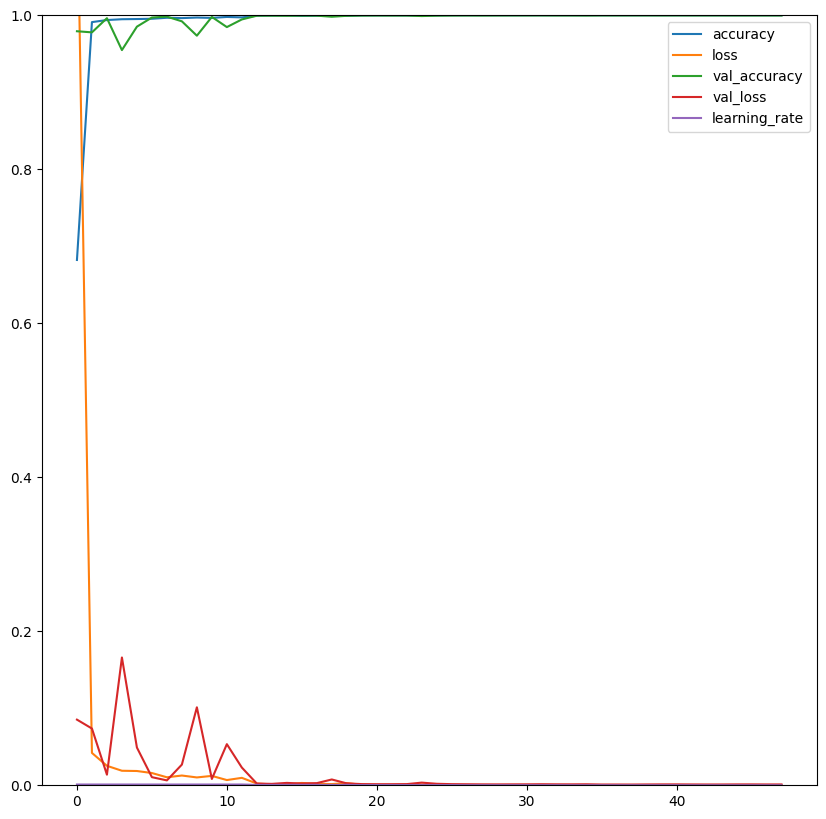

In [60]:
pd.DataFrame(model_compiled.history).plot(figsize=(10,10))
plt.grid(False)
plt.gca().set_ylim(0,1)
plt.show()

In [61]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd 
from PIL import Image

In [62]:
main_dir = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
IMAGE_HEIGHT = 30
IMAGE_WIDTH = 30
batch_size = 500

test_csv = pd.read_csv(main_dir + '/Test.csv')
labels = test_csv['ClassId'].values # contains the true labels of these images  
imgs = test_csv['Path'].values # contains the file path to the images in the test file 

In [63]:
preds = [] # to store the models predictrions 

for i in range(0,len(imgs),batch_size): # iterate through 0 to to the last of all the image file paths in test csv , we loop it as per memeoy
    # in the compuert available to controld this memory we use batch_Size 
    b_images = imgs[i:i + batch_size] # slicing the images from i to the i + batch size and take only thoase images for looping 
    b_data = [] # we store the details of the image batch wise in this list 

    for img in b_images:
        image = cv2.imread(main_dir + '/' + img)
        if image is not None:
            image_fromarray = Image.fromarray(image,'RGB')
            resize_image = image_fromarray.resize((IMAGE_HEIGHT,IMAGE_WIDTH))
            b_data.append(np.array(resize_image,dtype = np.float32 )/255.0)
        # we iterste through the images batch wise and convert the image to PIL form if there is an image we convert it from BGR format to the 
        # RGB format and then resize based on our needs and convert them to float ( due to memory issues float64 cdnt be used ) and cobvert  them 
        # to a numpy array by dividing with 255 to get the exact value as 0 - black and 255 - white 
    
    if b_data: # checks of b_data has any images in it 
        batch_array = np.array(b_data) # convert the dta to an numpy array 
        print("Batch data shape:",batch_array.shape)
        preds_batch = model.predict(batch_array) # we predict based on the current batch 
        preds.append(preds_batch) # we collect the predictions of all the batches in predictions 

preds = np.vstack(preds) # vstqack stacks the predictions row wise of all the of all the batch wise array predictions in pres_batch
pred_classes = np.argmax(preds,axis = 1) # This line identifies the predicted class for each image based on the prediction probabilities.
# by specifying axis = 1 we say taht we want the maximum value accriss each row 

Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Batch data shape: (500, 3

In [64]:
print('Testing accuracy ' , accuracy_score(labels,pred_classes) * 100)
# here labels is the true class labels and pred_classes is the prediction by the CNN model 

Testing accuracy  98.74901029295329


Confusion matrix is a performace tool that tells us the actual postive or false positive or actual negetive or false negetive , through a mtrix format 

In [65]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(labels,pred_classes)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


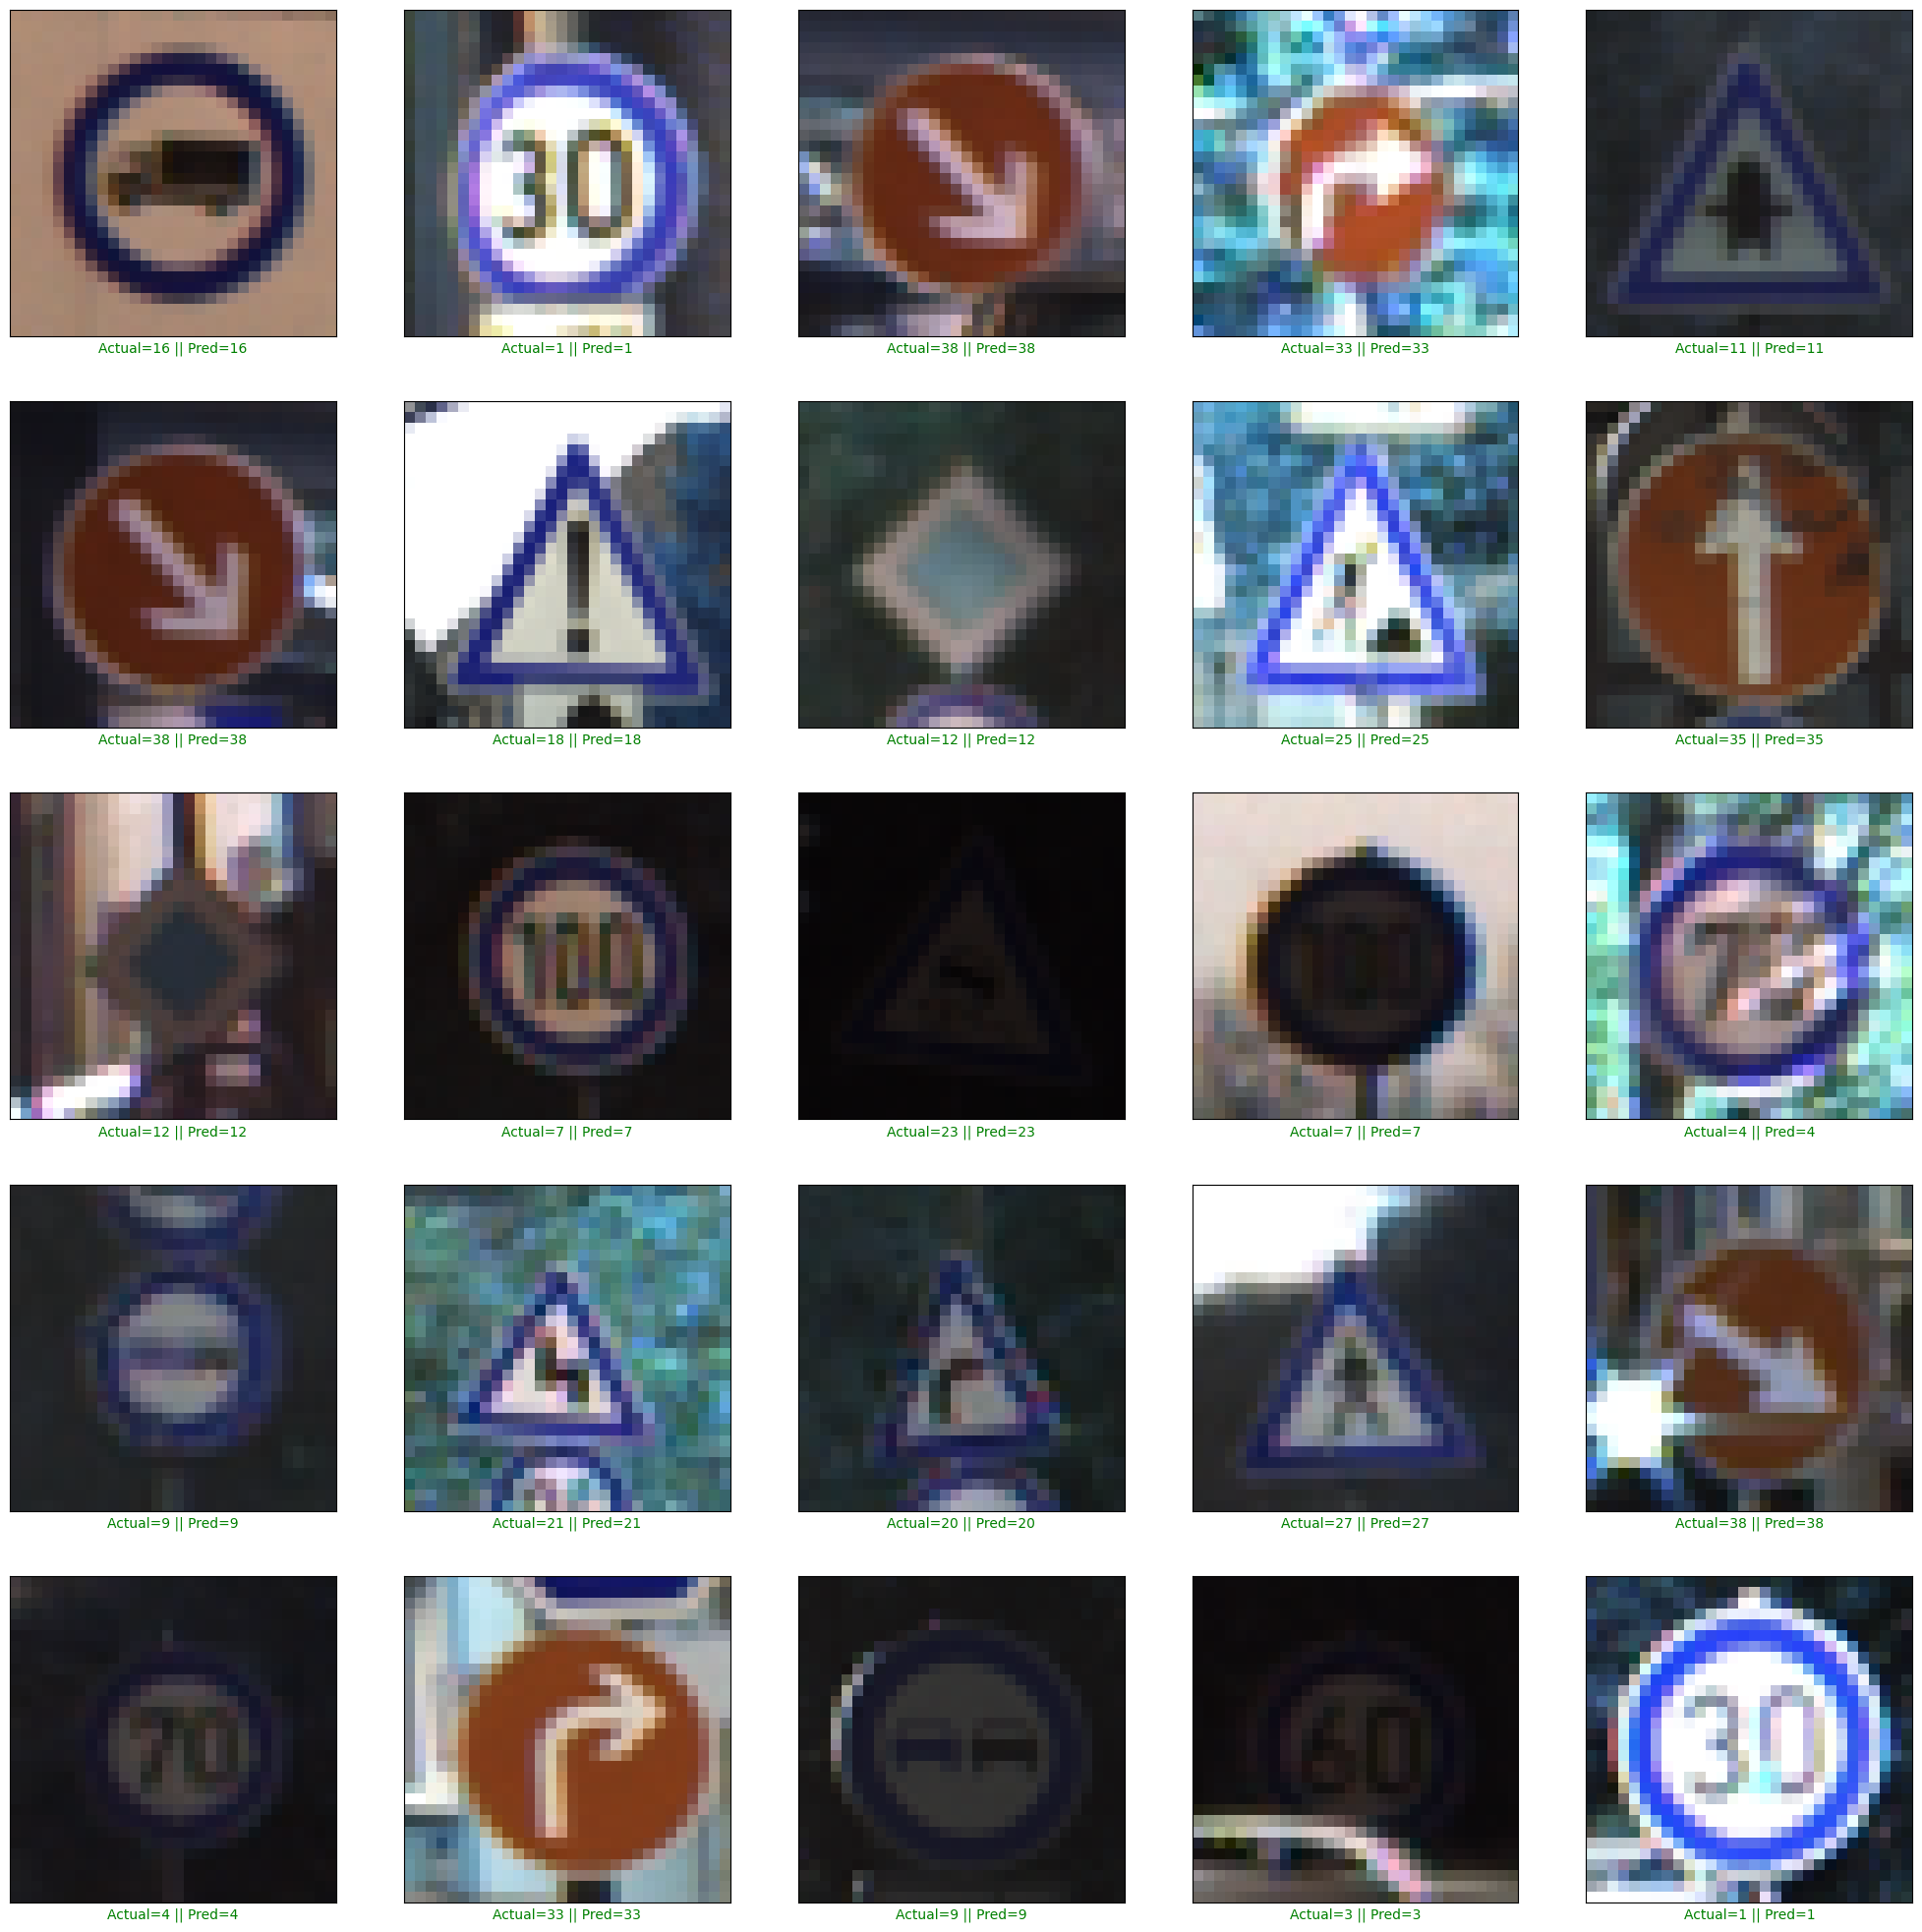

In [66]:
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import load_model

predictions = []
all_images = []  

for i in range(0, len(imgs), batch_size):
    batch_imgs = imgs[i:i + batch_size]
    batch_data = []

    for img in batch_imgs:
        image = cv2.imread(main_dir + '/' + img)
        if image is not None:
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMAGE_HEIGHT, IMAGE_WIDTH))
            batch_data.append(np.array(resize_image, dtype=np.float32) / 255.0)
            all_images.append(resize_image)  # Store the original image

    if batch_data:  # Check if the batch is not empty
        batch_array = np.array(batch_data)
        predictions_batch = model.predict(batch_array)  # Predict for this batch
        predictions.append(predictions_batch)

# Step 5: Combine all predictions
if predictions:  # Check if any predictions were made
    predictions = np.vstack(predictions)  # Stack all batch predictions
    pred_classes = np.argmax(predictions, axis=1)

    # Step 6: Evaluate accuracy
    print('Test Data accuracy: ', accuracy_score(labels, pred_classes) * 100)
    
    # Visualization
    plt.figure(figsize=(25, 25))
    num_images_to_display = min(25, len(pred_classes))  
    for i in range(num_images_to_display):
        plt.subplot(5, 5, i + 1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        prediction = pred_classes[i]
        actual = labels[i]
        col = 'g' if prediction == actual else 'r'
        plt.xlabel('Actual={} || Pred={}'.format(actual, prediction), color=col)

        # Show the original images
        plt.imshow(all_images[i])
    plt.show()
else:
    print("No predictions were made.")

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report

In [42]:
precision = precision_score(labels,pred_classes,average = "weighted")
precision

0.9801372007587076

In [43]:
recall = recall_score(labels,pred_classes,average="weighted")
recall

0.9796516231195566

In [44]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(labels,pred_classes,output_dict=True)

report_data = pd.DataFrame(report).transpose()

print(report_data)

              precision    recall  f1-score       support
0              1.000000  1.000000  1.000000     60.000000
1              0.987637  0.998611  0.993094    720.000000
2              0.985507  0.997333  0.991385    750.000000
3              0.988584  0.962222  0.975225    450.000000
4              0.996970  0.996970  0.996970    660.000000
5              0.946889  0.990476  0.968192    630.000000
6              1.000000  0.866667  0.928571    150.000000
7              0.997778  0.997778  0.997778    450.000000
8              0.992941  0.937778  0.964571    450.000000
9              0.973577  0.997917  0.985597    480.000000
10             1.000000  0.995455  0.997722    660.000000
11             0.990099  0.952381  0.970874    420.000000
12             0.978386  0.984058  0.981214    690.000000
13             0.997222  0.997222  0.997222    720.000000
14             0.985401  1.000000  0.992647    270.000000
15             0.995261  1.000000  0.997625    210.000000
16            